# 01 — Coleta e Tratamento de Dados

**Propósito:** Conecta às APIs externas (BCB/SGS, BCB/Expectativas, yfinance, IPEA), consolida, trata e transforma os dados. Gera **todos os CSVs** que os demais notebooks consomem.

> ⚠️ **Só execute este notebook quando quiser atualizar os dados.** Para trabalhar nos modelos use os notebooks 02-07 com os CSVs já presentes em `data/`.

| | |
|---|---|
| **Entradas** | APIs externas (internet necessária) |
| **Saídas** | `data/br_transformado.csv`, `data/bsts_train.csv`, `data/bsts_test.csv`, `data/causal_forest_train.csv`, `data/causal_forest_test.csv` |
| **Ordem** | Primeiro; gera os dados para todos os outros notebooks |


In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


In [2]:
# Bibliotecas para coleta e tratamento
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd

from bcb import sgs, Expectativas
import yfinance as yf
import pandas_datareader.data as web
import ipeadatapy as ipea

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor

import requests


#Coleta de dados

In [3]:
selic_00_09 = sgs.get({'br_selic': 11}, start=DATA_INICIO, end='2009-12-31')
selic_10_19 = sgs.get({'br_selic': 11}, start='2010-01-01', end='2019-12-31')
selic_20_24 = sgs.get({'br_selic': 11}, start='2020-01-01', end=DATA_FIM)
br_selic = pd.concat([selic_00_09, selic_10_19, selic_20_24])
br_selic = br_selic.sort_index()
br_selic.columns = ['br_selic']


In [4]:
print(br_selic.head())
print(br_selic.describe())
print(br_selic.isnull().sum())


            br_selic
Date                
2000-01-03  0.069186
2000-01-04  0.069186
2000-01-05  0.069220
2000-01-06  0.069286
2000-01-07  0.069286
          br_selic
count  6279.000000
mean      0.045347
std       0.017557
min       0.007469
25%       0.033784
50%       0.044698
75%       0.056683
max       0.092855
br_selic    0
dtype: int64


In [5]:
dolar_00_09 = sgs.get({'br_dolar': 1}, start=DATA_INICIO, end='2009-12-31')
dolar_10_19 = sgs.get({'br_dolar': 1}, start='2010-01-01', end='2019-12-31')
dolar_20_24 = sgs.get({'br_dolar': 1}, start='2020-01-01', end=DATA_FIM)
br_dolar = pd.concat([dolar_00_09, dolar_10_19, dolar_20_24])
br_dolar = br_dolar.sort_index()
br_dolar.columns = ['br_dolar']


In [6]:
print(br_dolar.head())
print(br_dolar.describe())
print(br_dolar.isnull().sum())


            br_dolar
Date                
2000-01-03    1.8011
2000-01-04    1.8337
2000-01-05    1.8544
2000-01-06    1.8461
2000-01-07    1.8281
          br_dolar
count  6279.000000
mean      3.085083
std       1.259003
min       1.534500
25%       2.034100
50%       2.726400
75%       3.862550
max       6.199100
br_dolar    0
dtype: int64


In [7]:
# IDs utilizados pelo SGS
series_ids = {
    'br_ipca': 433,# IPCA (inflação)
    'br_pib': 4380,# PIB (Trimestral)
    #'br_cambio_dolar': 3695, #Cambio(Dolar)
}

df_brasil = sgs.get(list(series_ids.values()), start=DATA_INICIO, end=DATA_FIM) #Extraindo com o periodo desejado
df_brasil.columns = series_ids.keys()
df_brasil.head()


,br_ipca,br_pib
Date,,
2000-01-01,0.62,92576.6
2000-02-01,0.13,91770.4
2000-03-01,0.22,92579.9
2000-04-01,0.42,91376.2
2000-05-01,0.01,98727.0


In [8]:
# --- Bloco de Expectativas (Nível Diário) ---
expectativas = Expectativas()
data_inicio = DATA_INICIO
data_fim = DATA_FIM
ep_mensais = expectativas.get_endpoint('ExpectativaMercadoMensais')

consulta = ep_mensais.query() \
        .filter(ep_mensais.Indicador == 'IPCA') \
        .filter(ep_mensais.Data >= data_inicio, ep_mensais.Data <= data_fim) \
        .collect()
df = pd.DataFrame(consulta)

# Tratamento para obter a expectativa para 12 meses à frente, em base diária
df['Data'] = pd.to_datetime(df['Data'])
df['DataReferencia'] = pd.to_datetime(df['DataReferencia'], format='mixed')

# Para cada data de pesquisa, calculamos qual seria o mês de referência alvo (12 meses à frente)
df['MesPesquisa'] = df['Data'].dt.to_period('M').dt.to_timestamp()
df['MesAlvo12M'] = df['MesPesquisa'] + pd.DateOffset(months=12)

# Filtramos o DataFrame, mantendo apenas as previsões para o alvo de 12 meses
df_12m = df[df['DataReferencia'] == df['MesAlvo12M']].copy()

# Para cada dia de pesquisa, pegamos o último valor reportado.
df_final = df_12m.sort_values('Data').drop_duplicates(subset=['Data'], keep='last')

# Selecionamos as colunas e definimos o índice
df_final_exp = df_final[['Data', 'Media']].rename(columns={'Media': 'ipca_expectativa'})
df_final_exp = df_final_exp.set_index('Data')
df_final_exp.head()


,ipca_expectativa
Data,
2001-11-06,0.34
2001-11-07,0.31
2001-11-08,0.32
2001-11-09,0.31
2001-11-12,0.32


In [9]:
# IDs utilizados pelo yahoo finance BR
series_ids_yf_br = {
    'br_ibov': '^BVSP',#Ibovespa
    #'br_ewz': 'EWZ',#ewz (a partir do mes 7 apenas)
}

tickers = list(series_ids_yf_br.values())
df_br_yf = yf.download(tickers, start=DATA_INICIO, end=DATA_FIM)['Close']
ticker_map = {v: k for k, v in series_ids_yf_br.items()}
df_br_yf.columns = [ticker_map.get(col, col) for col in df_br_yf.columns]

display(df_br_yf.head())


[*********************100%***********************]  1 of 1 completed


,br_ibov
Date,
2000-01-03,16930.0
2000-01-04,15851.0
2000-01-05,16245.0
2000-01-06,16107.0
2000-01-07,16309.0


In [10]:
#Metrica risco-pais
codigo_embi = 'JPM366_EMBI366'

# Busca a série temporal completa
embi_brasil = ipea.timeseries(codigo_embi)

# A função ipea.timeseries retorna um DataFrame com um MultiIndex.
embi_brasil = embi_brasil['VALUE (-)'].to_frame(name='embi_brasil')

# Filtragem de data
start_date = DATA_INICIO
embi_brasil = embi_brasil[embi_brasil.index >= start_date]

embi_brasil.head()


,embi_brasil
DATE,
2000-01-01,NaN
2000-01-02,NaN
2000-01-03,626.0
2000-01-04,675.0
2000-01-05,677.0


##Consolidação e Analise Incial

In [11]:
#juntando bases
br_full = pd.concat([br_selic, br_dolar, df_brasil, df_br_yf, embi_brasil, df_final_exp], axis=1, sort=False)
br_full.head()


,br_selic,br_dolar,br_ipca,br_pib,br_ibov,embi_brasil,ipca_expectativa
2000-01-03,0.069186,1.8011,NaN,NaN,16930.0,626.0,NaN
2000-01-04,0.069186,1.8337,NaN,NaN,15851.0,675.0,NaN
2000-01-05,0.069220,1.8544,NaN,NaN,16245.0,677.0,NaN
2000-01-06,0.069286,1.8461,NaN,NaN,16107.0,688.0,NaN
2000-01-07,0.069286,1.8281,NaN,NaN,16309.0,677.0,NaN


In [12]:
#analise basica df
print("Informações gerais da base:\n")
print(f"Linha/Coluna: {br_full.shape}")
print("\nTipos de dados:")
print(br_full.dtypes)

print("\n Valores nulos por coluna:")
print(br_full.isnull().sum())

print("\nEstatísticas descritivas:")
display(br_full.describe())


Informações gerais da base:

Linha/Coluna: (8218, 7)

Tipos de dados:
br_selic            float64
br_dolar            float64
br_ipca             float64
br_pib              float64
br_ibov             float64
embi_brasil         float64
ipca_expectativa    float64
dtype: object

 Valores nulos por coluna:
br_selic            1939
br_dolar            1939
br_ipca             7918
br_pib              7918
br_ibov             2027
embi_brasil         1883
ipca_expectativa    2407
dtype: int64

Estatísticas descritivas:


,br_selic,br_dolar,br_ipca,br_pib,br_ibov,embi_brasil,ipca_expectativa
count,6279.000000,6279.000000,300.000000,3.000000e+02,6191.000000,6335.000000,5811.000000
mean,0.045347,3.085083,0.501133,4.275930e+05,60859.276207,390.254933,0.386028
std,0.017557,1.259003,0.394905,2.561878e+05,34525.789157,307.451967,0.121276
min,0.007469,1.534500,-0.680000,9.137620e+04,8371.000000,136.000000,0.130000
25%,0.033784,2.034100,0.260000,1.953456e+05,35833.000000,221.000000,0.300000
50%,0.044698,2.726400,0.450000,3.999756e+05,56864.000000,271.000000,0.370000
75%,0.056683,3.862550,0.675000,5.855786e+05,84125.000000,418.000000,0.460000
max,0.092855,6.199100,3.020000,1.045166e+06,137344.000000,2443.000000,0.850000


#Tratando os Dados

In [13]:
# Interpolar primeiro as séries de baixa frequência (IPCA e PIB)
# Criamos um índice diário completo para o período e depois interpolamos.
indice_diario_completo = pd.date_range(start=df_brasil.index.min(), end=df_brasil.index.max(), freq='D')
df_brasil_interpolado = df_brasil.reindex(indice_diario_completo).interpolate(method='linear')
df_brasil_interpolado.head()


,br_ipca,br_pib
2000-01-01,0.620000,92576.600000
2000-01-02,0.604194,92550.593548
2000-01-03,0.588387,92524.587097
2000-01-04,0.572581,92498.580645
2000-01-05,0.556774,92472.574194


In [14]:
## Teste de Sensibilidade da Interpolacao
if USE_LOCAL_DATA:
    print("Teste de sensibilidade ignorado no modo local (requer dados da internet).")
    print("Para executar, rode em modo completo com todas as celulas de coleta de dados.")
else:
    metodos_interpolacao = {
        'linear': df_brasil.reindex(indice_diario_completo).interpolate(method='linear'),
        'ffill':  df_brasil.reindex(indice_diario_completo).ffill(),
        'spline': df_brasil.reindex(indice_diario_completo).interpolate(method='spline', order=3),
    }
    resultados_sensibilidade = []
    for nome_metodo, df_metodo in metodos_interpolacao.items():
        for col in ['br_ipca', 'br_pib']:
            serie = df_metodo[col].dropna()
            adf_p  = adfuller(serie)[1]
            kpss_p = kpss(serie, regression='c', nlags='auto')[1]
            resultados_sensibilidade.append({
                'Metodo': nome_metodo,
                'Variavel': col,
                'ADF p-valor': round(adf_p, 4),
                'ADF Estacionaria (p<0.05)': 'Sim' if adf_p < 0.05 else 'Nao',
                'KPSS p-valor': round(kpss_p, 4),
                'KPSS Estacionaria (p>0.05)': 'Sim' if kpss_p > 0.05 else 'Nao',
            })
    df_sensibilidade = pd.DataFrame(resultados_sensibilidade)
    print("=== Teste de Sensibilidade da Interpolacao ===")
    display(df_sensibilidade)
    diag = df_sensibilidade.groupby('Variavel')[['ADF Estacionaria (p<0.05)', 'KPSS Estacionaria (p>0.05)']].nunique()
    consistente = (diag == 1).all().all()
    msg = "Sim" if consistente else "Nao - revisar metodo de interpolacao"
    print(f"Diagnostico consistente entre os tres metodos: {msg}")

Teste de sensibilidade ignorado no modo local (requer dados da internet).
Para executar, rode em modo completo com todas as celulas de coleta de dados.


In [15]:
# Definir o índice mestre com os dias de negociação do Ibovespa
# Usamos o 'br_ibov' como referência de dias úteis.
df_diario = pd.DataFrame(index=df_br_yf.index)

# Juntar todas as séries de dados ao índice mestre
# Agora usamos o df_brasil_interpolado, que já está em frequência diária.
df_diario = pd.concat([
    df_br_yf,
    br_selic,
    br_dolar,
    df_brasil_interpolado, # base já interpolada
    df_final_exp,
    embi_brasil
], axis=1, sort=False)

# Remove quaisquer linhas no início que ainda possam ser nulas (final de semana e inicio)
df_diario = df_diario.dropna()


In [16]:
df_diario.head()


,br_ibov,br_selic,br_dolar,br_ipca,br_pib,ipca_expectativa,embi_brasil
2001-11-06,12416.0,0.069186,2.6003,0.700,117071.116667,0.34,1123.0
2001-11-07,12616.0,0.069220,2.6055,0.698,116908.940000,0.31,1083.0
2001-11-08,12554.0,0.069186,2.5571,0.696,116746.763333,0.32,1054.0
2001-11-09,12731.0,0.069186,2.5347,0.694,116584.586667,0.31,1054.0
2001-11-12,12567.0,0.069220,2.5502,0.688,116098.056667,0.32,1074.0


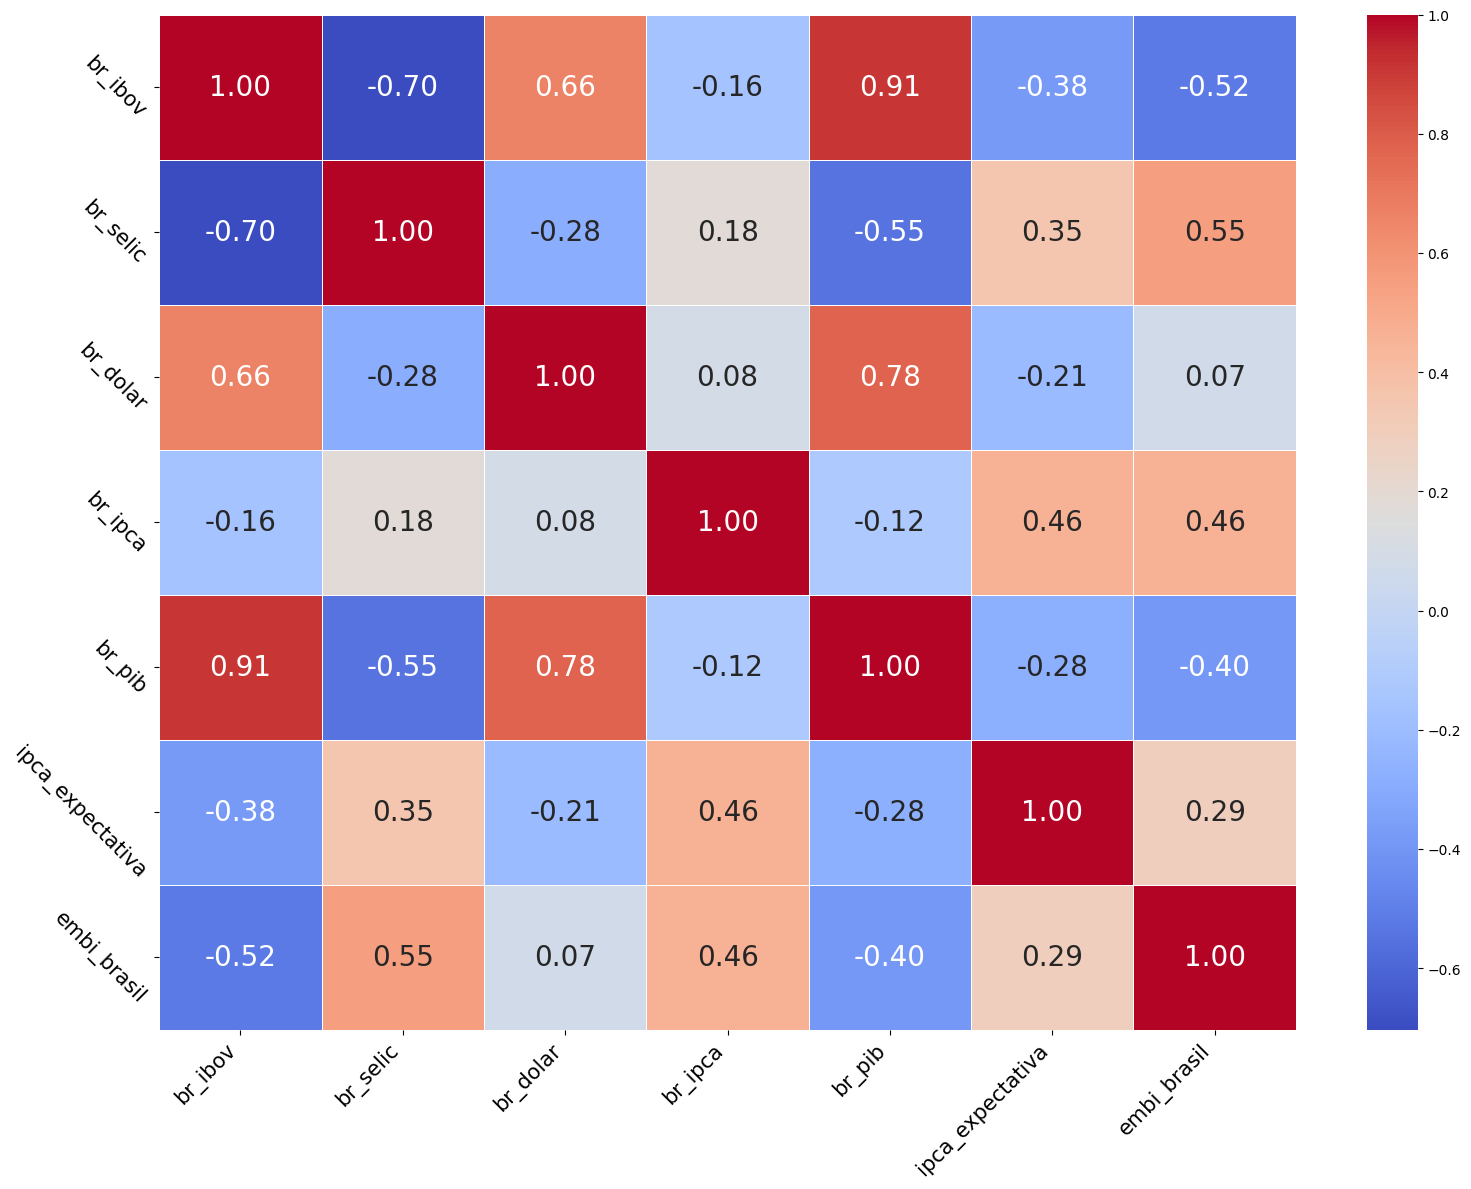

In [17]:
# Análise Brasil Transformada
# Calcula a matriz de correlação
matriz_corr = df_diario.corr()

# Cria o mapa de calor usando seaborn
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_corr,
    annot=True,
    annot_kws={'size': 20},
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
plt.xticks(fontsize=15, rotation=45, ha='right')
plt.yticks(fontsize=15, rotation=-45)
plt.tight_layout() # Adicionado para melhor ajuste do gráfico
plt.show()


##Analise Dados Tratados

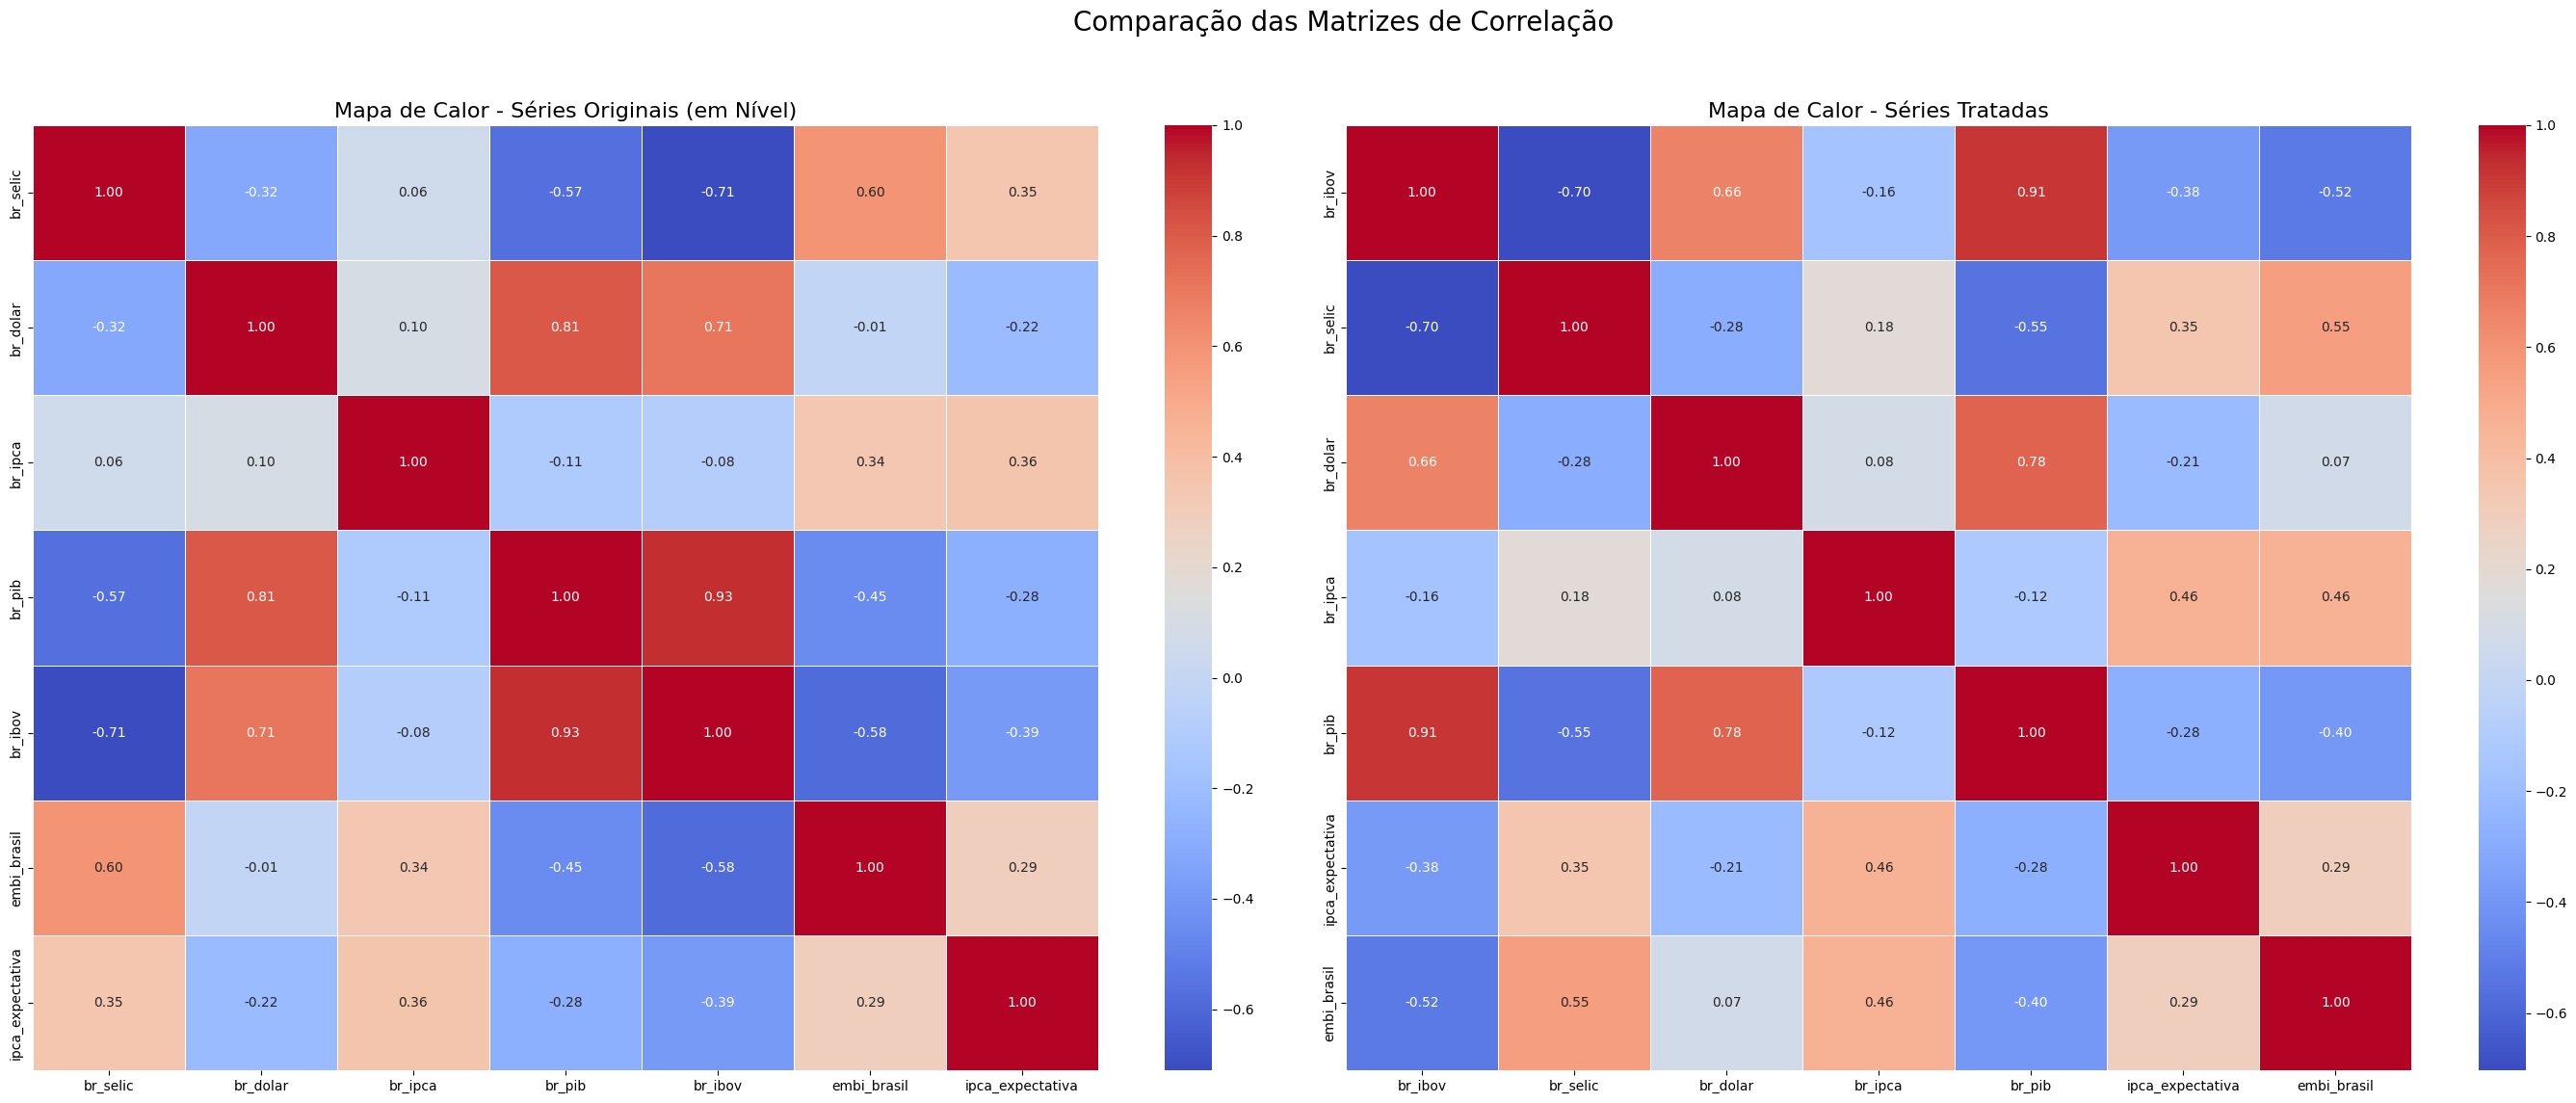

In [18]:
# Cria uma figura com dois subplots (1 linha, 2 colunas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(28, 12))

# Define a ordem das variáveis com base no DataFrame original
ordem_original = br_full.columns.tolist()
ordem_tratada = df_diario.columns.tolist()


# Mapa de Calor 1: Séries Originais (br_full)
# Calcula a correlação e reordena para garantir a ordem
matriz_corr_original = br_full.corr().reindex(index=ordem_original, columns=ordem_original)
sns.heatmap(matriz_corr_original, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[0])
axes[0].set_title('Mapa de Calor - Séries Originais (em Nível)', fontsize=16)

# Mapa de Calor 2: Séries Transformadas (df_diario)
# Calcula a correlação e reordena para corresponder à ordem
matriz_corr_transformada = df_diario.corr().reindex(index=ordem_tratada, columns=ordem_tratada)
sns.heatmap(matriz_corr_transformada, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[1])
axes[1].set_title('Mapa de Calor - Séries Tratadas', fontsize=16)


fig.suptitle('Comparação das Matrizes de Correlação', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#Teste de Estacionaridade Dados Tratados

In [19]:
def rodar_testes_estacionariedade(df):
    resultados = []
    print("\nRodando testes de estacionariedade...")
    for coluna in df.columns:
        try:
            teste_adf = adfuller(df[coluna].dropna())
            p_valor_adf = teste_adf[1]
            teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
            p_valor_kpss = teste_kpss[1]
            resultados.append({'Variável': coluna, 'P-valor ADF': p_valor_adf, 'P-valor KPSS': p_valor_kpss})
        except Exception as e:
            resultados.append({'Variável': coluna, 'P-valor ADF': f"Erro: {e}", 'P-valor KPSS': f"Erro: {e}"})
    df_resultados = pd.DataFrame(resultados)
    return df_resultados.set_index('Variável')

# Roda os testes na base de dados em nível (já tratada)
resultados_estacionariedade = rodar_testes_estacionariedade(df_diario)
print("\n--- Resultados dos Testes de Estacionariedade (Séries em Nível) ---")
display(resultados_estacionariedade)



Rodando testes de estacionariedade...


C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: 


--- Resultados dos Testes de Estacionariedade (Séries em Nível) ---


C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")


,P-valor ADF,P-valor KPSS
Variável,,
br_ibov,7.530374e-01,0.010000
br_selic,2.578476e-01,0.010000
br_dolar,9.595087e-01,0.010000
br_ipca,3.829140e-10,0.054709
br_pib,9.985175e-01,0.010000
ipca_expectativa,3.254514e-06,0.010000
embi_brasil,9.637756e-02,0.010000


#Transformando dados Não Estacionarios

In [20]:
# Criando uma nova base de dados para as séries transformadas
br_transformado = pd.DataFrame(index=df_diario.index)

# Aplicando as transformações
for coluna in df_diario.columns:
    # Copia a coluna do IPCA diretamente, pois já é estacionária
    if 'br_ipca' == coluna:
        br_transformado[coluna] = df_diario[coluna]
    # Para séries de preços ou índices, usamos o retorno logarítmico
    elif coluna in COLUNAS_LOG_RETORNO:
        br_transformado[f'{coluna}_ret_log'] = np.log(df_diario[coluna]).diff()
    # Para as outras métricas, usamos a primeira diferença
    else:
        br_transformado[f'{coluna}_diff'] = df_diario[coluna].diff()

# Remove a primeira linha que será NaN após a diferenciação
br_transformado = br_transformado.dropna()

print("\n--- Base de Dados Brasileira Transformada (Diferenciada) ---")
display(br_transformado.head())

# Agora, rodamos os testes de estacionariedade novamente na base transformada
print("\n--- Testando a Estacionariedade da Base Transformada ---")
resultados_transformado = rodar_testes_estacionariedade(br_transformado)
display(resultados_transformado)



--- Base de Dados Brasileira Transformada (Diferenciada) ---


,br_ibov_ret_log,br_selic_diff,br_dolar_diff,br_ipca,br_pib_ret_log,ipca_expectativa_diff,embi_brasil_diff
2001-11-07,0.015980,0.000034,0.0052,0.698,-0.001386,-0.03,-40.0
2001-11-08,-0.004927,-0.000034,-0.0484,0.696,-0.001388,0.01,-29.0
2001-11-09,0.014001,0.000000,-0.0224,0.694,-0.001390,-0.01,0.0
2001-11-12,-0.012966,0.000034,0.0155,0.688,-0.004182,0.01,20.0
2001-11-13,0.027547,0.000000,-0.0232,0.686,-0.001398,0.01,-64.0



--- Testando a Estacionariedade da Base Transformada ---

Rodando testes de estacionariedade...


C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  teste_kpss = kpss(df[coluna].dropna(), regression='c', nlags="auto")
C:\Users\Lucao\AppData\Local\Temp\ipykernel_4260\4021788753.py:8: InterpolationWarning: 

,P-valor ADF,P-valor KPSS
Variável,,
br_ibov_ret_log,0.000000e+00,0.100000
br_selic_diff,1.320857e-09,0.100000
br_dolar_diff,1.141714e-29,0.100000
br_ipca,3.837500e-10,0.055014
br_pib_ret_log,2.090362e-27,0.100000
ipca_expectativa_diff,0.000000e+00,0.100000
embi_brasil_diff,7.128875e-22,0.100000


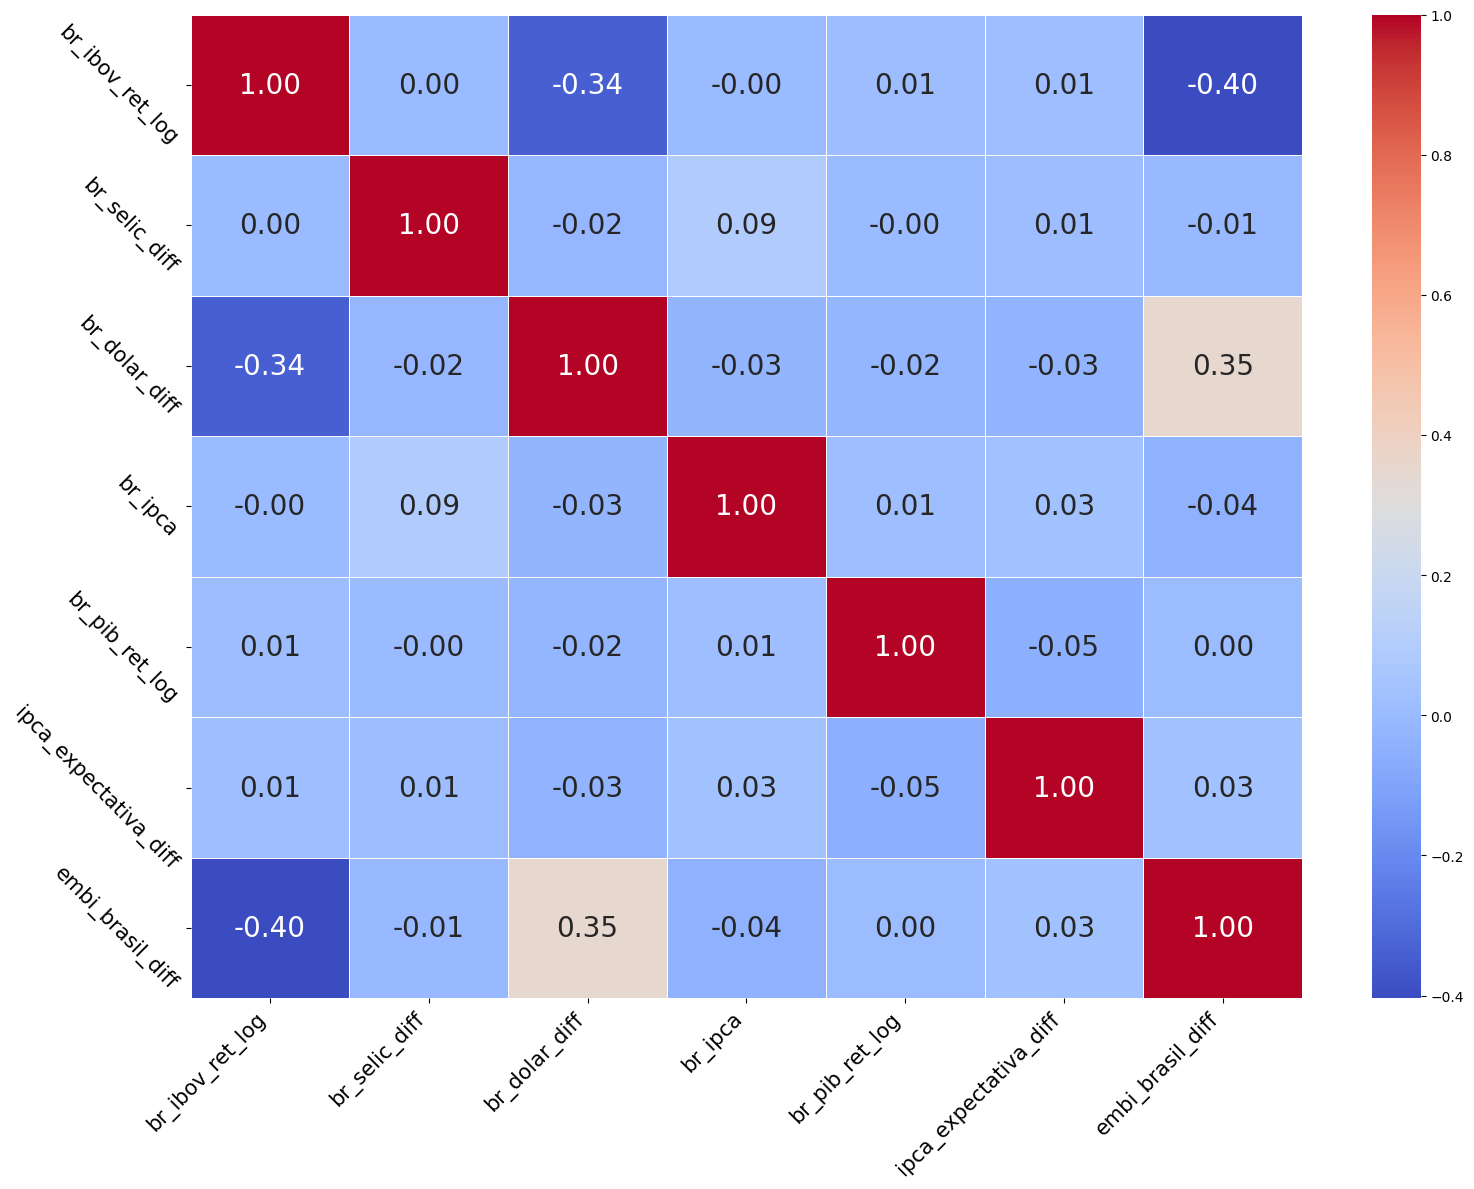

In [21]:
# Análise Brasil Transformada
# Calcula a matriz de correlação
matriz_corr = br_transformado.corr()

# Cria o mapa de calor usando seaborn
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_corr,
    annot=True,
    annot_kws={'size': 20},
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
plt.xticks(fontsize=15, rotation=45, ha='right')
plt.yticks(fontsize=15, rotation=-45)
plt.tight_layout() # Adicionado para melhor ajuste do gráfico
plt.show()


## Exportação dos Dados Transformados

In [22]:
# Persiste a série transformada (fonte única para todos os notebooks de modelo)
br_transformado.to_csv(DATA_DIR / 'br_transformado.csv')
print(f"br_transformado.csv salvo em data/: {br_transformado.shape}")
print(f"Colunas: {br_transformado.columns.tolist()}")
print(f"Período: {br_transformado.index[0].date()} → {br_transformado.index[-1].date()}")


br_transformado.csv salvo em data/: (5598, 7)
Colunas: ['br_ibov_ret_log', 'br_selic_diff', 'br_dolar_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']
Período: 2001-11-07 → 2024-07-30


## Geração dos CSVs de Entrada por Modelo

In [23]:
# Split treino/teste — mesmo corte usado por todos os modelos
train = br_transformado[br_transformado.index < DATA_SPLIT_DATE]
test  = br_transformado[br_transformado.index >= DATA_SPLIT_DATE]
print(f"Treino ({DATA_SPLIT_DATE}): {train.shape} | Teste: {test.shape}")


Treino (2020-01-01): (4481, 7) | Teste: (1117, 7)


### BSTS

In [24]:
# BSTS — treino e teste (mesmas colunas de br_transformado)
df_bsts_train = train.copy()
df_bsts_test  = test.copy()
df_bsts_train.to_csv(DATA_DIR / 'bsts_train.csv')
df_bsts_test.to_csv(DATA_DIR / 'bsts_test.csv')
print(f"bsts_train.csv: {df_bsts_train.shape} | bsts_test.csv: {df_bsts_test.shape}")
print(f"Período treino: {df_bsts_train.index[0].date()} → {df_bsts_train.index[-1].date()}")
print(f"Período teste:  {df_bsts_test.index[0].date()}  → {df_bsts_test.index[-1].date()}")


bsts_train.csv: (4481, 7) | bsts_test.csv: (1117, 7)
Período treino: 2001-11-07 → 2019-12-30
Período teste:  2020-01-02  → 2024-07-30


### Causal Forest — Tratamento `T_choque_dolar`

O limiar p75 é calculado **somente no conjunto de treino** (2001–2019) para evitar
vazamento de informação do teste na definição do tratamento.


In [25]:
# Causal Forest — tratamento binário baseado em choque cambial
br_cf = br_transformado.copy()
mask_train    = br_cf.index < DATA_SPLIT_DATE
limiar_dolar  = br_cf.loc[mask_train, 'br_dolar_diff'].abs().quantile(0.75)
br_cf['T_choque_dolar'] = (br_cf['br_dolar_diff'].abs() >= limiar_dolar).astype(int)

train_cf = br_cf[br_cf.index < DATA_SPLIT_DATE]
test_cf  = br_cf[br_cf.index >= DATA_SPLIT_DATE]

train_cf.to_csv(DATA_DIR / 'causal_forest_train.csv')
test_cf.to_csv(DATA_DIR / 'causal_forest_test.csv')

print(f"causal_forest_train.csv: {train_cf.shape} | test: {test_cf.shape}")
print(f"Limiar dólar (p75 treino): {limiar_dolar:.6f}")
print(f"Prevalência T=1 treino:  {train_cf['T_choque_dolar'].mean():.1%}")
print(f"Prevalência T=1 teste:   {test_cf['T_choque_dolar'].mean():.1%}")


causal_forest_train.csv: (4481, 8) | test: (1117, 8)
Limiar dólar (p75 treino): 0.022900
Prevalência T=1 treino:  25.0%
Prevalência T=1 teste:   55.9%
